In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('cleaned_data.csv')
df

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


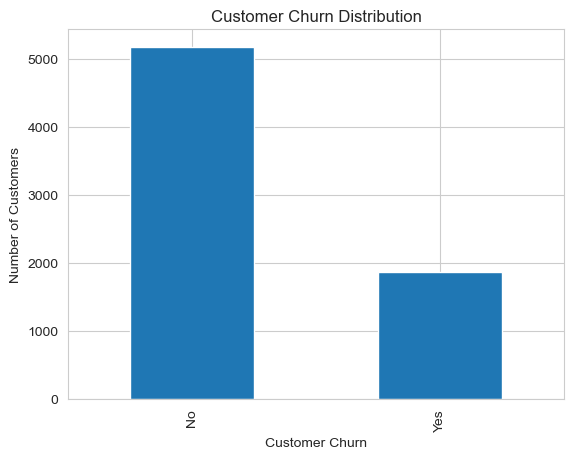

In [4]:
#Check how many customers churns or not in this dataset:

df['Churn'].value_counts().plot(kind='bar', title='Customer Churn Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Customer Churn')
plt.show()

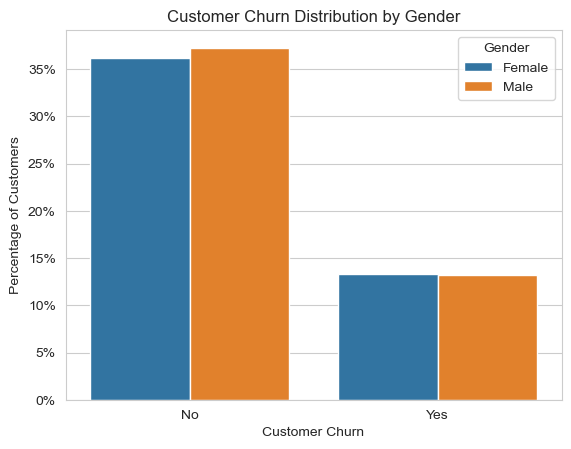

In [5]:
#let's dive deeper by getting the count based on the gender

df_gender_churn = df.groupby('Gender')['Churn'].value_counts().reset_index()
df_gender_churn['total'] = df_gender_churn['count'].sum()
df_gender_churn['percent'] = 100 * df_gender_churn['count'] / df_gender_churn['total']

sns.barplot(data=df_gender_churn, y='percent', x='Churn', hue='Gender')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
plt.title('Customer Churn Distribution by Gender')
plt.ylabel('Percentage of Customers')
plt.xlabel('Customer Churn')
plt.show()
#gender seeems not to play role in customer churn.
#confirm this using hypothesis testing.

### Reason for using Chi-Square for Test of Independence
**Assumptions are met**:
- Both are categorical variables .
- Mutually exclusive and independent.
- Each categories are of have at least frequency of 5

**Null Hypothesis**: The two variables are independent of each other.

**Alternative Hypothesis**: The two variables are dependent on each other.


In [6]:
g_chi_table = pd.crosstab(df['Gender'], df['Churn'])
print('Contingency Table:\n', g_chi_table)

chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(g_chi_table)

print(f'\nChi-square statistic: {chi2_statistic}')
print(f'P-value: {p_value}')
print(f'Degrees of freedom: {degrees_of_freedom}')
print(f'Expected frequencies:\n {expected_frequencies}')

# Since p-value > 0.05, we fail to reject the null hypothesis. 
# Hence, there is no enough proof to show that Gender has significant relationship with customer churn.

Contingency Table:
 Churn     No  Yes
Gender           
Female  2549  939
Male    2625  930

Chi-square statistic: 0.4840828822091383
P-value: 0.48657873605618596
Degrees of freedom: 1
Expected frequencies:
 [[2562.38989067  925.61010933]
 [2611.61010933  943.38989067]]


Looking at another perspective, we check if customer churn is related to the age of the customers.

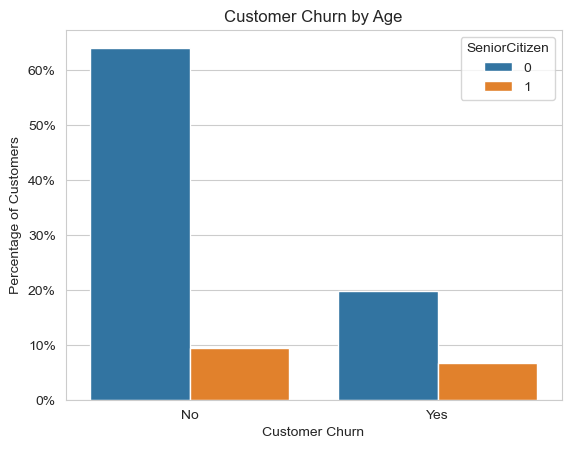

In [7]:
df_sc_churn = df.groupby('SeniorCitizen')['Churn'].value_counts().reset_index()
df_sc_churn['total'] = df_sc_churn['count'].sum()
df_sc_churn['percent'] = 100 * df_sc_churn['count'] / df_sc_churn['total']

sns.barplot(data=df_sc_churn, y='percent', x='Churn', hue='SeniorCitizen')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
plt.title('Customer Churn by Age')
plt.ylabel('Percentage of Customers')
plt.xlabel('Customer Churn')
plt.show()



Looking at the graph, it seems that age seems to have relationship with customer churn. Let's confirm this using Chi-Square test for independence.

In [8]:
sc_chi_table = pd.crosstab(df['SeniorCitizen'], df['Churn'])
print('Contingency Table:\n', sc_chi_table)

chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(sc_chi_table)

print(f'\nChi-square statistic: {chi2_statistic}')
print(f'P-value: {p_value}')
print(f'Degrees of freedom: {degrees_of_freedom}')
print(f'Expected frequencies:\n {expected_frequencies}')

Contingency Table:
 Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476

Chi-square statistic: 159.42630036838742
P-value: 1.510066805092378e-36
Degrees of freedom: 1
Expected frequencies:
 [[4335.05239245 1565.94760755]
 [ 838.94760755  303.05239245]]


Having P-value < 0.05, we say that there is enough evidence to say that customer churn and customer age are correlated to each other.
This signals to explore the common things in respective age brackets.

In [ ]:
# Why and how does age affect customer churn?
# Compare demographics of same age but different churn
    # Find trends in churning and non-churning customer of same age. Some info might be revealed such as lack of source of income, etc.

# Compare the demographics of each age bracket

df_sc = df.query('SeniorCitizen == 1').copy()
df_not_sc = df.query('SeniorCitizen == 0').copy()